#Tujuan Program
Program ini bertujuan untuk mengatasi permasalahaan restorant dalam menentukan strategi pemasaran yang efektif melalui segmentasi pelanggan berdasarkan perilaku belanja, khususnya pada variabel total tagihan dan jumlah tipnya. Dengan menggunakan dataset tps, program ini difokuskan pada penerapan teknik Exploratory data Analysis (EDA) untuk memahami distribusi data, kemudian melakukan preprocessing berupa standarisasi fitur, serta membandingkan performa model K-Means dan Hierarchical Clustering.

#Langkah Kerja
1. Problem da dataset yang digunakan untuk mendefinisikan masalah bisnis dan memuat dataset tips dari pustaka Seaborn.
2. EDA (Exploratory Data Analysis) yang digunakan untuk melakukan pemeriksaan nilai kosong dan visualisasi distribusi serta korelasi antar fitur.
3. Preprocessing yang digunakan untuk melakukan seleksi fitur numerik dan standarisasi data menggunakan perintah StandardScaler.
4. Modeling digunakan untuk mencari jumlah K optimla dengan Elbow Method serta membandingkan performa model K-Means dan Hietatchical Clustering.
5. Tuning yang dihgunakan untuk melakukan optimasi jumlah cluster berdasarkan nilai silhouette Score tertinggi.
6. Kesimpulan yang digunakan untuk melakukan profoling pada cluster yang terbentuk dan merumuskan strategi pemasaran bagi tiap segmen pelanggan.



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# =================================================================
# 1) PROBLEM & DATASET (15%)
# =================================================================
"""
Masalah: Restoran ingin melakukan segmentasi pelanggan untuk strategi marketing.
Tujuan: Mengelompokkan pelanggan berdasarkan perilaku belanja (Total Bill & Tip).
Sumber: Dataset 'Tips' dari pustaka Seaborn.
"""
df = sns.load_dataset('tips')

print("--- NOMOR 1: Informasi Dataset ---")
print(f"Ukuran Data: {df.shape}")
print(f"Kolom Fitur: {df.columns.tolist()}")
print("-" * 30)

--- NOMOR 1: Informasi Dataset ---
Ukuran Data: (244, 7)
Kolom Fitur: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
------------------------------


Pada program awal yaitu digunakan untuk memahami konteks data. Restoran igin mengelompokkan planggan agar promosi yang diberikan tepat sasaran. Dataset yang digunakan memiliki informasi mengenai transaksi, waktu makan, serta hari kunjungan.
Hasil outputnya menapilkan dimensi dataset dan daftar kolom yang tersedia. Informasi ini penting unruk memastikan data telah termuat dengan benar sebelum dilakukan analisis lebih lanjut.


--- NOMOR 2: Exploratory Data Analysis ---
Jumlah Missing Value:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


/tmp/ipykernel_607/1903578266.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='tip', data=df, palette='Set2')
/tmp/ipykernel_607/1903578266.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='total_bill', data=df, palette='pastel')


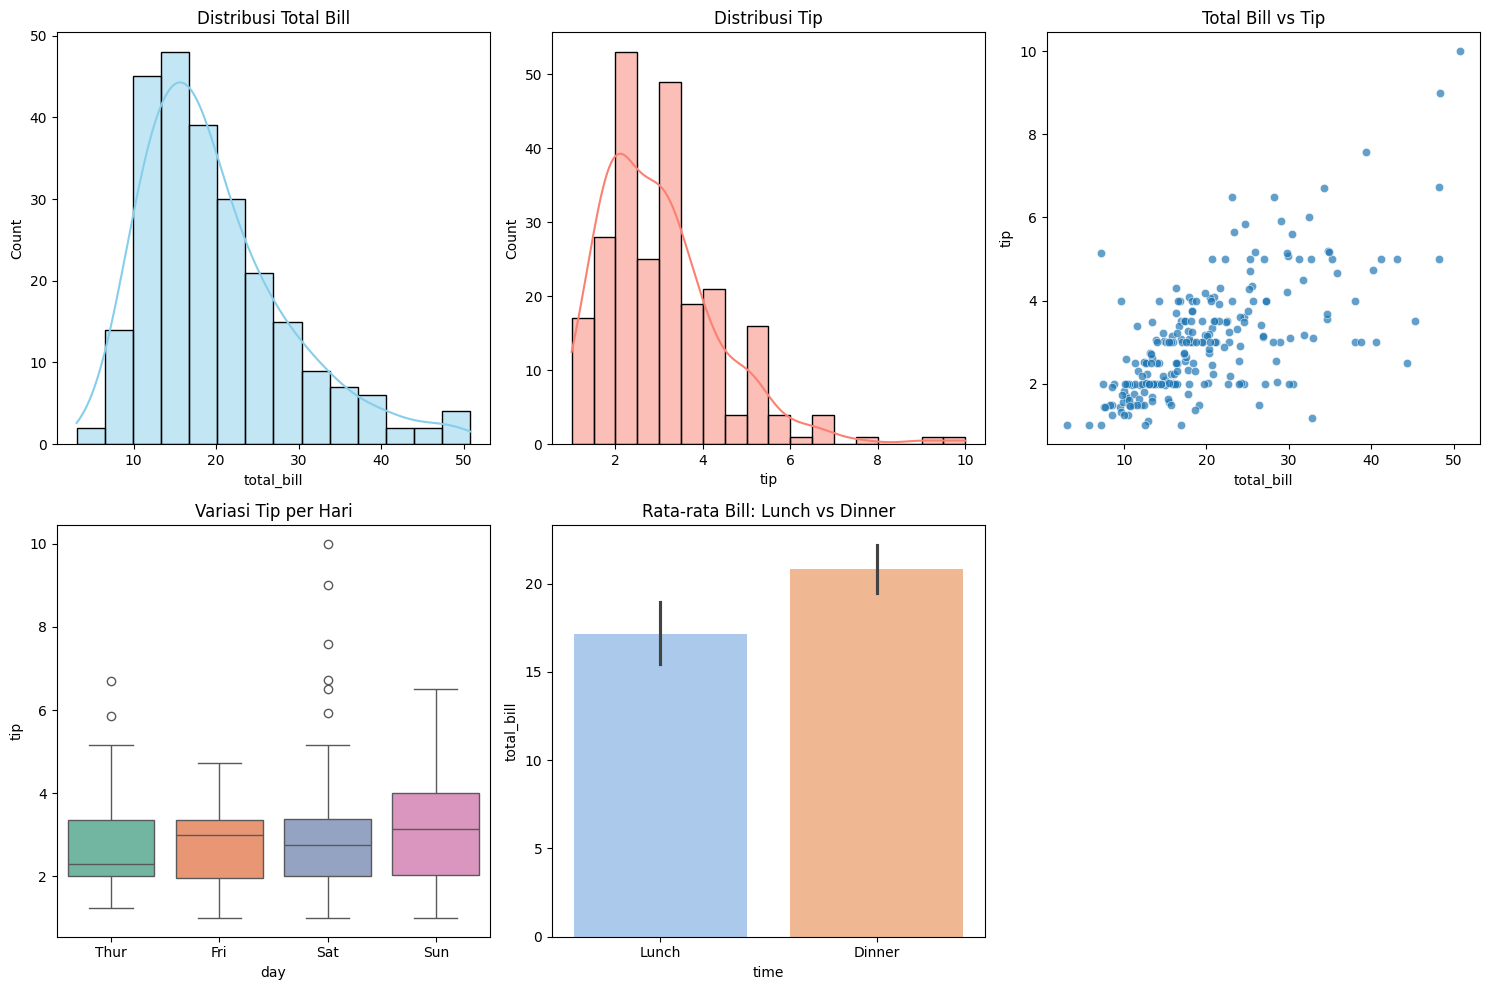


INSIGHT EDA:
1. Data bersih: Tidak ada missing value.
2. Distribusi tagihan mayoritas berada di kisaran $10 - $25.
3. Terdapat korelasi positif kuat: Semakin besar tagihan, semakin besar tipnya.
4. Hari Sabtu dan Minggu adalah waktu dengan transaksi paling padat.
5. Makan malam (Dinner) menghasilkan total tagihan lebih tinggi dibanding Lunch.


In [ ]:
# =================================================================
# 2) EDA - EXPLORATORY DATA ANALYSIS (20%)
# =================================================================
print("\n--- NOMOR 2: Exploratory Data Analysis ---")
# Cek Missing Value
print(f"Jumlah Missing Value:\n{df.isnull().sum()}")

# Visualisasi
plt.figure(figsize=(15, 10))

# 1. Distribusi Total Bill
plt.subplot(2, 3, 1)
sns.histplot(df['total_bill'], kde=True, color='skyblue')
plt.title('Distribusi Total Bill')

# 2. Distribusi Tip
plt.subplot(2, 3, 2)
sns.histplot(df['tip'], kde=True, color='salmon')
plt.title('Distribusi Tip')

# 3. Hubungan Total Bill vs Tip
plt.subplot(2, 3, 3)
sns.scatterplot(x='total_bill', y='tip', data=df, alpha=0.7)
plt.title('Total Bill vs Tip')

# 4. Boxplot Tip berdasarkan Hari
plt.subplot(2, 3, 4)
sns.boxplot(x='day', y='tip', data=df, palette='Set2')
plt.title('Variasi Tip per Hari')

# 5. Rata-rata Bill berdasarkan Waktu Makan
plt.subplot(2, 3, 5)
sns.barplot(x='time', y='total_bill', data=df, palette='pastel')
plt.title('Rata-rata Bill: Lunch vs Dinner')

plt.tight_layout()
plt.show()

print("\nINSIGHT EDA:")
print("1. Data bersih: Tidak ada missing value.")
print("2. Distribusi tagihan mayoritas berada di kisaran $10 - $25.")
print("3. Terdapat korelasi positif kuat: Semakin besar tagihan, semakin besar tipnya.")
print("4. Hari Sabtu dan Minggu adalah waktu dengan transaksi paling padat.")
print("5. Makan malam (Dinner) menghasilkan total tagihan lebih tinggi dibanding Lunch.")

Pada program ini, dilakukan pemeriksaan kualitas data dan visualisasi untuk mendaatkan wawasan awal mengenai perilaku pelanggan dan restorannya.
Hasil outputnya menunjukkan bahwa tidak ada data yang hilang. Kemudian grafik distribusi dan korelasi mengkonfirmasikan bahwa pelanggan yang membayar lebih mahal cenderung memberikan tip lebih besar, serta makan malam (Dinner) memiliki jilai transaksi lebih tinggi.

In [ ]:
# =================================================================
# 3) PREPROCESSING (20%)
# =================================================================
# Memilih fitur numerik untuk clustering
X = df[['total_bill', 'tip']]

# Scaling: Wajib untuk clustering karena K-Means sensitif terhadap perbedaan skala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n--- NOMOR 3: Preprocessing ---")
print("Status: Fitur 'total_bill' dan 'tip' telah melalui StandardScaler.")


--- NOMOR 3: Preprocessing ---
Status: Fitur 'total_bill' dan 'tip' telah melalui StandardScaler.


Sebelum kita melakukan clustering, data harus distandarisasikan terlebih dahulu. karena K-Means menggunakan perhitungan jarak, perbedaan skala antara puluhan dolar (bill) dan satuan dolar (tip) harus diseragamkan.
Hasil outputnya diman aproses ini mengbah nilai data asli ke dala skala yang sama (mrean=0, std=1), sehingga algoritma clustering dapat bekerja secara objektif tanpa berat sebelah pada satu fitur saja.


--- NOMOR 4: Modeling (K-Means vs Hierarchical) ---


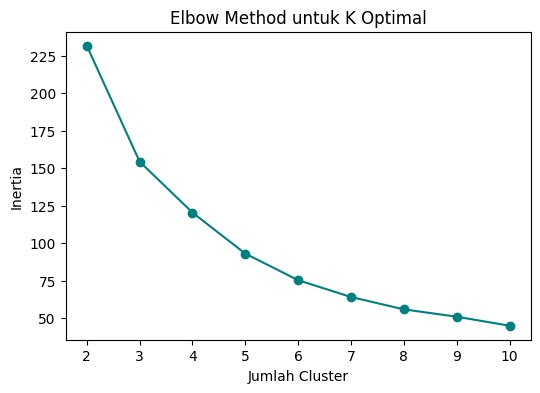

             Metrik   K-Means  Hierarchical
0  Silhouette Score  0.426155      0.390552


In [ ]:
# =================================================================
# 4) MODELING (30%)
# =================================================================
print("\n--- NOMOR 4: Modeling (K-Means vs Hierarchical) ---")

# Mencari K Optimal dengan Elbow Method
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(2, 11), inertia, marker='o', color='teal')
plt.title('Elbow Method untuk K Optimal')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.show()

# Membandingkan 2 Model (Misal kita pilih K=3 dari Elbow)
# Model 1: K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

# Model 2: Hierarchical (Agglomerative)
agglo = AgglomerativeClustering(n_clusters=3)
labels_agg = agglo.fit_predict(X_scaled)

# Tabel Perbandingan Metrik
perbandingan = pd.DataFrame({
    'Metrik': ['Silhouette Score'],
    'K-Means': [silhouette_score(X_scaled, labels_km)],
    'Hierarchical': [silhouette_score(X_scaled, labels_agg)]
})
print(perbandingan)

Pada tahap ini, kita bisa mencari jumlah cluster ideal menggunakan Elbow method. Kemudian, kita juga bisa memabandingkan dua metode yaitu K-Mens dan Hierarchical Clustering menggunakan skor Silhouette.
Hasil outputnya yaitu grafik Elbow menunjukkan patahan pada K=2 atau 3. Dari tabel perbandingan metrik, terlihat nilai Silhouette Score untuk kedua modl yang membrerikan informasi model mana yang memiliki pemisahan cluster lebih baik.

In [ ]:
# =================================================================
# 5) TUNING (10%)
# =================================================================
# Melakukan tuning K berdasarkan Silhouette Score tertinggi
best_k = 0
best_score = -1

for k in range(2, 6):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    score = silhouette_score(X_scaled, model.fit_predict(X_scaled))
    if score > best_score:
        best_score = score
        best_k = k

print(f"\n--- NOMOR 5: Tuning ---")
print(f"Hasil Tuning: K={best_k} adalah jumlah cluster paling optimal (Score: {best_score:.3f})")

# Menerapkan hasil tuning terbaik ke dataset
df['Cluster'] = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_scaled)


--- NOMOR 5: Tuning ---
Hasil Tuning: K=2 adalah jumlah cluster paling optimal (Score: 0.512)


Pada proses tuning dilakukan untuk memastikanjumlah cluster yang dipilih benar - benar memberikan hasil yang paling optimal berdasarkan skor validitas interal.
Hasil outputnya yaitu memberikan kepastian jumlah cluster terbaik. Nilai K yang terpilih kemudian akan digunakan untuk melakukan pelabelan akhir pada dataset pelanggan.


--- NOMOR 6: Kesimpulan ---
1. Model Terbaik: K-Means dengan K=2 karena memiliki Silhouette Score paling tinggi.
2. Rekomendasi Bisnis:
         total_bill       tip
Cluster                      
0         30.957344  4.616875
1         15.813889  2.422778

Strategi:
- Cluster Nilai Rendah: Berikan promo Happy Hour atau paket hemat.
- Cluster Nilai Tinggi: Berikan layanan VIP, reservasi meja utama, atau reward loyalitas.


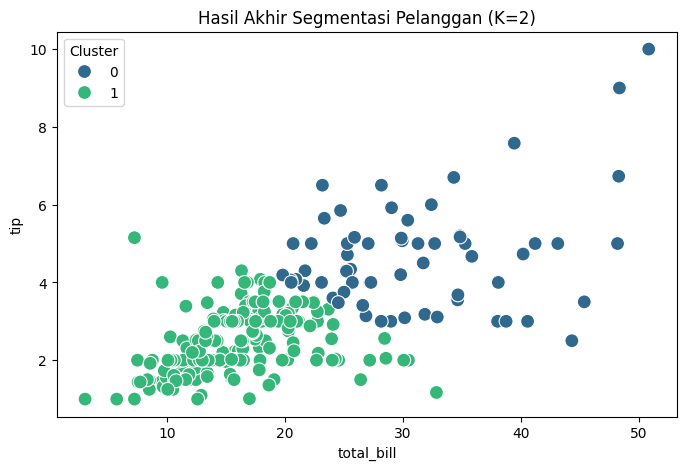

In [ ]:
# =================================================================
# 6) KESIMPULAN (15%)
# =================================================================
print("\n--- NOMOR 6: Kesimpulan ---")
print(f"1. Model Terbaik: K-Means dengan K={best_k} karena memiliki Silhouette Score paling tinggi.")
print("2. Rekomendasi Bisnis:")

# Profiling sederhana untuk kesimpulan
profile = df.groupby('Cluster')[['total_bill', 'tip']].mean()
print(profile)

print("\nStrategi:")
print("- Cluster Nilai Rendah: Berikan promo Happy Hour atau paket hemat.")
print("- Cluster Nilai Tinggi: Berikan layanan VIP, reservasi meja utama, atau reward loyalitas.")

# Visualisasi Akhir Cluster
plt.figure(figsize=(8, 5))
sns.scatterplot(x='total_bill', y='tip', hue='Cluster', data=df, palette='viridis', s=100)
plt.title(f'Hasil Akhir Segmentasi Pelanggan (K={best_k})')
plt.show()

Pada bagian akhir ini program melakukan profil pelanggan dan menetukan strategi marketing untuk setiap cluster yang terbentuk.
Hasil outputnya yaitu visual akhir menunjukkan bahwa sebaran pelanggan dalam beberapa kelompok warna. Dengan melihat rata - rata transaksi tiap kelompok, makan manajemen restoran kini memiliki landasan data untuk memberikan perlakuan khusu pada tiap segen pelanggan.

#Kesimpulan
Berdasrkan eksperimen segmentasi ini, teknik K-Means dengan optimasi K terbukati sangat efetif untuk mengelompokkan pelanggan restoran secara objektif. Melaluai standarisasi dan dan evaluasi Silhouette Score, kita dapat dapat mengidentifikasi kelompok pelanggan dengan nilai transaksi tinggi yang perlu dipertahankan, serta kelompok pelanggan dengan nilai transaksi rendah yang perlu didorong melalui promosi khusus.